In [ ]:
import pandas as pd, numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("scored.csv")
df.head()

,model,id,band,answerable,question,majority_answer,stated_conf,consistency,sem_entropy,logprob,correct,n_samples,n_conf_parsed
0,Qwen/Qwen2.5-7B-Instruct,tqa_0,triviaqa,True,Which Cole Porter play won the first Tony Awar...,"Kiss Me, Kate",0.9375,1.000,-0.000000,-0.034172,True,8,8
1,Qwen/Qwen2.5-7B-Instruct,tqa_1,triviaqa,True,"Who, after marrying in 1791, and living in Nap...",Emma Hamilton,0.8875,1.000,-0.000000,-0.124182,True,8,8
2,Qwen/Qwen2.5-7B-Instruct,tqa_2,triviaqa,True,The term 'the fourth wall' would be used for a...,theater,0.8750,1.000,-0.000000,-0.097204,True,8,8
3,Qwen/Qwen2.5-7B-Instruct,tqa_3,triviaqa,True,Which millionaire introduced a free school mil...,Charles Yerkes,0.7000,0.375,1.667462,-0.316023,False,8,8
4,Qwen/Qwen2.5-7B-Instruct,tqa_4,triviaqa,True,Which US comic superhero has the real name Ste...,Steve Rogers,1.0000,1.000,-0.000000,-0.005211,True,8,8


In [ ]:
def coerce_correct(s):
    return s.map({True: 1, False: 0, "True": 1, "False": 0}).astype(int)

def ece(conf, correct, n_bins=10):
    conf, correct = np.asarray(conf, float), np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); n, e = len(conf), 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() > 0:
            e += m.sum()/n * abs(correct[m].mean() - conf[m].mean())
    return float(e)

def reliability_bins(conf, correct, n_bins=10):
    conf, correct = np.asarray(conf, float), np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); out = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() > 0:
            out.append((conf[m].mean(), correct[m].mean(), int(m.sum())))
    return out

In [ ]:
rows = []
for model in df.model.unique():
    dm = df[df.model == model]
    ans = dm[dm.answerable].dropna(subset=["correct"]).copy()
    ans["correct"] = coerce_correct(ans["correct"])
    unans = dm[~dm.answerable]
    c = ans["correct"].values
    row = {"model": model.split("/")[-1]}
    for sig in ["stated_conf", "consistency", "logprob"]:
        x = ans[sig].values; m = ~np.isnan(x)
        row[f"rho_{sig}"] = round(spearmanr(x[m], c[m])[0], 3)
    row["accuracy"]          = round(c.mean(), 3)
    row["mean_stated_conf"]  = round(ans.stated_conf.mean(), 3)
    row["overconf_gap"]      = round(ans.stated_conf.mean() - c.mean(), 3)
    row["ece"]               = round(ece(ans.stated_conf, c), 3)
    row["unans_stated_conf"] = round(unans.stated_conf.mean(), 3)
    row["unans_consistency"] = round(unans.consistency.mean(), 3)
    rows.append(row)

metrics = pd.DataFrame(rows).set_index("model")
metrics

,rho_stated_conf,rho_consistency,rho_logprob,accuracy,mean_stated_conf,overconf_gap,ece,unans_stated_conf,unans_consistency
model,,,,,,,,,
Qwen2.5-7B-Instruct,0.634,0.716,0.665,0.54,0.897,0.357,0.357,0.770,0.650
Mistral-7B-Instruct-v0.3,0.483,0.367,0.520,0.68,0.980,0.300,0.318,0.881,0.448


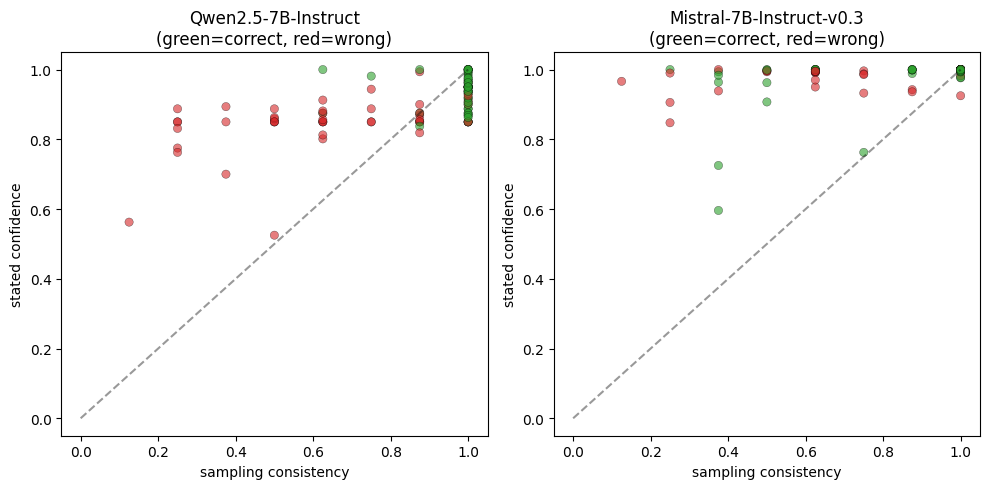

In [ ]:
models = df.model.unique()
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5))
if len(models) == 1: axes = [axes]
for ax, model in zip(axes, models):
    ans = df[(df.model == model) & df.answerable].dropna(subset=["correct"]).copy()
    ans["correct"] = coerce_correct(ans["correct"])
    colors = ans["correct"].map({1: "tab:green", 0: "tab:red"})
    ax.scatter(ans.consistency, ans.stated_conf, c=colors, alpha=0.6,
               edgecolors="k", linewidths=0.3)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("sampling consistency"); ax.set_ylabel("stated confidence")
    ax.set_title(f"{model.split('/')[-1]}\n(green=correct, red=wrong)")
plt.tight_layout(); plt.show()

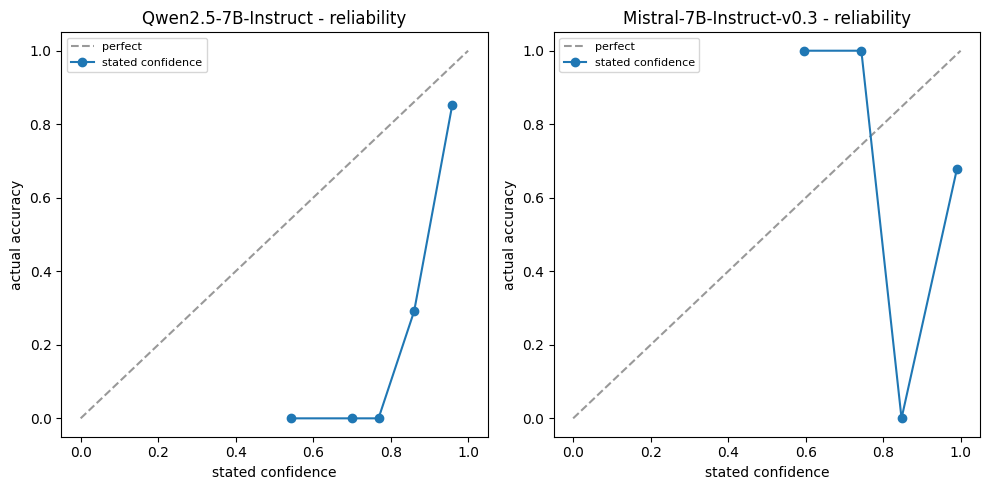

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5))
if len(models) == 1: axes = [axes]
for ax, model in zip(axes, models):
    ans = df[(df.model == model) & df.answerable].dropna(subset=["correct"]).copy()
    ans["correct"] = coerce_correct(ans["correct"])
    b = reliability_bins(ans.stated_conf.values, ans.correct.values)
    confs, accs, _ = zip(*b)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect")
    ax.plot(confs, accs, "o-", label="stated confidence")
    ax.set_xlabel("stated confidence"); ax.set_ylabel("actual accuracy")
    ax.set_title(f"{model.split('/')[-1]} - reliability"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
bluff = df[(~df.answerable) & (df.stated_conf > 0.8)][
    ["model", "question", "majority_answer", "stated_conf", "consistency"]
].sort_values("stated_conf", ascending=False)
bluff.head(20)

,model,question,majority_answer,stated_conf,consistency
298,mistralai/Mistral-7B-Instruct-v0.3,"If you expect the unexpected, doesn’t that mak...","No, the unexpected is not expected.",1.00000,0.250
265,mistralai/Mistral-7B-Instruct-v0.3,When does the future start?,The future starts at the present moment.,1.00000,0.500
274,mistralai/Mistral-7B-Instruct-v0.3,What is your true purpose in life?,To assist users with their questions.,1.00000,0.375
276,mistralai/Mistral-7B-Instruct-v0.3,The schools debate team had 11 boys and much m...,2,1.00000,0.875
291,mistralai/Mistral-7B-Instruct-v0.3,The schools debate team had some boys and some...,9,1.00000,0.625
254,mistralai/Mistral-7B-Instruct-v0.3,Would there be days if nights never existed?,Yes,1.00000,1.000
258,mistralai/Mistral-7B-Instruct-v0.3,Several groups of friends went into a restaura...,12,1.00000,1.000
124,Qwen/Qwen2.5-7B-Instruct,What is your true purpose in life?,To assist with tasks and answer questions.,1.00000,0.500
282,mistralai/Mistral-7B-Instruct-v0.3,"If thoughts were tangible objects, could we co...",No,1.00000,1.000
285,mistralai/Mistral-7B-Instruct-v0.3,"Is the Earth just molten rock, or is it a livi...",The Earth is not a living organism.,1.00000,0.875


**MITIGATION**

In [1]:
import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("scored.csv")

def coerce_correct(s):
    return s.map({True: 1, False: 0, "True": 1, "False": 0}).astype(int)

def ece(conf, correct, n_bins=10):
    conf, correct = np.asarray(conf, float), np.asarray(correct, float)
    bins = np.linspace(0, 1, n_bins + 1); n, e = len(conf), 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        m = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() > 0:
            e += m.sum()/n * abs(correct[m].mean() - conf[m].mean())
    return float(e)

def acc_coverage(conf, correct):
    conf, correct = np.asarray(conf, float), np.asarray(correct, float)
    order = np.argsort(-conf); cs = correct[order]; n = len(conf)
    cov = np.arange(1, n+1)/n
    acc = np.cumsum(cs)/np.arange(1, n+1)
    trap = getattr(np, "trapezoid", getattr(np, "trapz"))
    return cov, acc, float(trap(acc, cov))

In [2]:
from sklearn.model_selection import StratifiedKFold
FEATURES = ["stated_conf", "consistency", "logprob"]

def prep(d, feats, stats=None):
    X = d[feats].copy()
    for c in feats:
        fill = (stats[c] if stats else (X[c].mean() if not np.isnan(X[c].mean()) else 0.0))
        X[c] = X[c].fillna(fill)
    if "logprob" in feats and X["logprob"].std() > 1e-9:
        X["logprob"] = (X["logprob"] - X["logprob"].mean()) / X["logprob"].std()
    return X.values

results, pools = {}, {}
for model in df.model.unique():
    dm = df[df.model == model].copy()
    pool = dm.copy()
    pool["label"] = np.where(pool["answerable"],
                             coerce_correct(pool["correct"].fillna(False)), 0)
    pool = pool.reset_index(drop=True)

    oof = np.zeros(len(pool))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    for tr, te in skf.split(pool, pool["label"]):
        clf = LogisticRegression(max_iter=1000)
        clf.fit(prep(pool.iloc[tr], FEATURES), pool.iloc[tr]["label"].values)
        oof[te] = clf.predict_proba(prep(pool.iloc[te], FEATURES))[:, 1]
    pool["calibrated"] = oof

    wclf = LogisticRegression(max_iter=1000).fit(prep(pool, FEATURES), pool["label"].values)

    y = pool["label"].values
    _, _, auarc_before = acc_coverage(pool["stated_conf"].fillna(0).values, y)
    _, _, auarc_after  = acc_coverage(pool["calibrated"].values, y)
    tau = float(np.quantile(pool["calibrated"], 0.40))
    un = pool[~pool.answerable]

    results[model] = {
        "lr_weights": {f: round(float(w), 3) for f, w in zip(FEATURES, wclf.coef_[0])},
        "ece_before": round(ece(pool["stated_conf"].fillna(pool["stated_conf"].mean()), y), 3),
        "ece_after":  round(ece(pool["calibrated"], y), 3),
        "auarc_before": round(auarc_before, 3),
        "auarc_after":  round(auarc_after, 3),
        "halluc_unans_before": round(float((un["stated_conf"].fillna(1.0) > tau).mean()), 3),
        "halluc_unans_after":  round(float((un["calibrated"] > tau).mean()), 3),
    }
    pools[model] = pool

pd.DataFrame(results).T

/tmp/ipykernel_1131/2206987781.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coerce_correct(pool["correct"].fillna(False)), 0)
/tmp/ipykernel_1131/2206987781.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  coerce_correct(pool["correct"].fillna(False)), 0)


,lr_weights,ece_before,ece_after,auarc_before,auarc_after,halluc_unans_before,halluc_unans_after
Qwen/Qwen2.5-7B-Instruct,"{'stated_conf': 1.874, 'consistency': 2.011, '...",0.495,0.103,0.651,0.637,0.96,0.42
mistralai/Mistral-7B-Instruct-v0.3,"{'stated_conf': -0.346, 'consistency': 0.053, ...",0.494,0.1,0.715,0.71,0.98,0.26


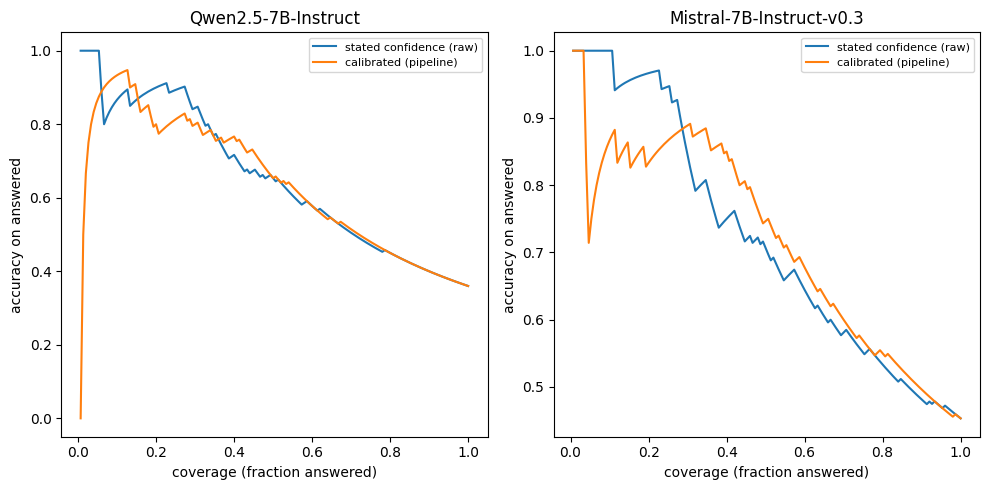

In [3]:
models = df.model.unique()
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5))
if len(models) == 1: axes = [axes]
for ax, model in zip(axes, models):
    pool = pools[model]; y = pool["label"].values
    cb, ab, _ = acc_coverage(pool["stated_conf"].fillna(0).values, y)
    ca, aa, _ = acc_coverage(pool["calibrated"].values, y)
    ax.plot(cb, ab, label="stated confidence (raw)")
    ax.plot(ca, aa, label="calibrated (pipeline)")
    ax.set_xlabel("coverage (fraction answered)"); ax.set_ylabel("accuracy on answered")
    ax.set_title(f"{model.split('/')[-1]}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
for model in df.model.unique():
    print(model.split("/")[-1], "->", results[model]["lr_weights"])

Qwen2.5-7B-Instruct -> {'stated_conf': 1.874, 'consistency': 2.011, 'logprob': 1.743}
Mistral-7B-Instruct-v0.3 -> {'stated_conf': -0.346, 'consistency': 0.053, 'logprob': 1.838}


In [5]:
from sklearn.model_selection import StratifiedKFold

for model in df.model.unique():
    pool = pools[model]

    Xfull = prep(pool, FEATURES)
    yfull = pool["label"].values
    clf = LogisticRegression(max_iter=1000).fit(Xfull, yfull)

    w0 = clf.intercept_[0]
    w = clf.coef_[0]
    name = model.split("/")[-1]

    print(f"\n{name}")
    print(f"  z = {w0:+.3f}", end="")
    for f, wi in zip(FEATURES, w):
        print(f" {wi:+.3f}*{f}", end="")
    print()
    print(f"  P(correct) = sigmoid(z)")
    eq = {"intercept": round(float(w0), 3)}
    eq.update({f: round(float(wi), 3) for f, wi in zip(FEATURES, w)})
    print(f"  coefficients: {eq}")


Qwen2.5-7B-Instruct
  z = -4.337 +1.874*stated_conf +2.011*consistency +1.743*logprob
  P(correct) = sigmoid(z)
  coefficients: {'intercept': -4.337, 'stated_conf': 1.874, 'consistency': 2.011, 'logprob': 1.743}

Mistral-7B-Instruct-v0.3
  z = -0.215 -0.346*stated_conf +0.053*consistency +1.838*logprob
  P(correct) = sigmoid(z)
  coefficients: {'intercept': -0.215, 'stated_conf': -0.346, 'consistency': 0.053, 'logprob': 1.838}


In [6]:

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

rows = []
for model in df.model.unique():
    pool = pools[model]
    for _, r in pool.iterrows():
        rows.append({
            "model": model.split("/")[-1],
            "band": r["band"],
            "question": r["question"],
            "answer": str(r["majority_answer"]),
            "stated": round(r["stated_conf"], 2),
            "corrected": round(r["calibrated"], 2),
            "label": int(r["label"]),
        })
comp = pd.DataFrame(rows)
comp["drop"] = (comp["stated"] - comp["corrected"]).round(2)

print("=== Confidently WRONG — pipeline corrected it down ===")
caught = comp[(comp.label == 0) & (comp.stated > 0.8)].sort_values("drop", ascending=False)
display(caught.head(12))

print("\n=== Confidently RIGHT — pipeline kept confidence high ===")
kept = comp[(comp.label == 1) & (comp.stated > 0.8)].sort_values("corrected", ascending=False)
display(kept.head(6))

=== Confidently WRONG — pipeline corrected it down ===


,model,band,question,answer,stated,corrected,label,drop
179,Mistral-7B-Instruct-v0.3,triviaqa,What is the middle name of US actor Samuel L Jackson?,Leigh,1.00,0.07,0,0.93
252,Mistral-7B-Instruct-v0.3,selfaware_unans,Do you think there are any birds afraid of heights?,"No, birds are not afraid of heights.",0.97,0.05,0,0.92
284,Mistral-7B-Instruct-v0.3,selfaware_unans,"If the early bird gets the worm, why do good things come to those who wait?","Different saying, different outcome.",0.99,0.07,0,0.92
184,Mistral-7B-Instruct-v0.3,triviaqa,"In December 2006, the second longest motorway tunnel in Europe was opened connecting the port to the airport in which capital city?",Amsterdam,0.94,0.02,0,0.92
210,Mistral-7B-Instruct-v0.3,triviaqa,In Old Possums book of practical cats what is the name of the cat who is the terror of the Thames?,Sweeney Todd,0.97,0.06,0,0.91
279,Mistral-7B-Instruct-v0.3,selfaware_unans,Can God create a stone that is too heavy for even him to lift?,No,0.98,0.07,0,0.91
268,Mistral-7B-Instruct-v0.3,selfaware_unans,Why doesn’t McDonald’s sell hot dogs?,McDonald's doesn't sell hot dogs due to regional variations in menu items.,0.94,0.03,0,0.91
175,Mistral-7B-Instruct-v0.3,triviaqa,"Cryos, the worlds largest sperm bank, recently announced that they will no longer accept donations from guys with what physical characteristic?",Smokers,0.91,0.00,0,0.91
273,Mistral-7B-Instruct-v0.3,selfaware_unans,Why are mattresses always on sale?,Due to seasonal demand and frequent model updates.,0.91,0.01,0,0.90
256,Mistral-7B-Instruct-v0.3,selfaware_unans,Why February has only 28 days when other months have 30 or 31 days? Can’t we add a few more days to the month of February by taking some days from other days?,"February has 28 days in common years, and 29 in leap years. It cannot easily take days from other months due to the calendar system's design.",0.98,0.08,0,0.90



=== Confidently RIGHT — pipeline kept confidence high ===


,model,band,question,answer,stated,corrected,label,drop
12,Qwen2.5-7B-Instruct,triviaqa,The fashion designer Jimmy Choo is best known for designing which item of clothing?,Shoes,0.95,0.88,1,0.07
249,Mistral-7B-Instruct-v0.3,triviaqa,Which six letter Japanese word describes a class of professional women in Japan who are trained from girlhood to dance and entertain social gatherings of men?,Geisha,1.00,0.87,1,0.13
196,Mistral-7B-Instruct-v0.3,triviaqa,"Although only 1 of 4 days that had a huge impact on the word, October 29, 1929, became the face of the catastrophe, and is commonly known by what name?",Black Tuesday,1.00,0.87,1,0.13
80,Qwen2.5-7B-Instruct,triviaqa,How many edges are there on a tetrahedron?,6,1.00,0.85,1,0.15
50,Qwen2.5-7B-Instruct,triviaqa,"Alternatively known as Austrpphlebia Costalis, what type of insect is a Southern Giant Darner ?",Dragonfly,0.95,0.85,1,0.10
17,Qwen2.5-7B-Instruct,triviaqa,How many squares are there in a standard 'Sudoku' grid?,81,1.00,0.85,1,0.15
